In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import sys
import os

# Make sure Python can find our src/ modules
sys.path.insert(0, "D:/Durability Analytics")
os.chdir("D:/Durability Analytics")

# Load config
from src.ingestion.loader import load_config, load_processed

config   = load_config()
datasets = load_processed(config)

df = datasets['pvs1']
print(f"Loaded pvs1: {len(df):,} rows, {len(df.columns)} columns")
print(f"Road types: {df['road_type'].value_counts().to_dict()}")

Loaded pvs1: 144,036 rows, 43 columns
Road types: {'cobblestone': 61659, 'asphalt': 56509, 'dirt': 25868}


  Computing PSD by road class...


  Per-dataset spectra: 100%|██████████| 2/2 [00:00<00:00, 10.39it/s]


  Saved psd_spectra.json (25 KB)


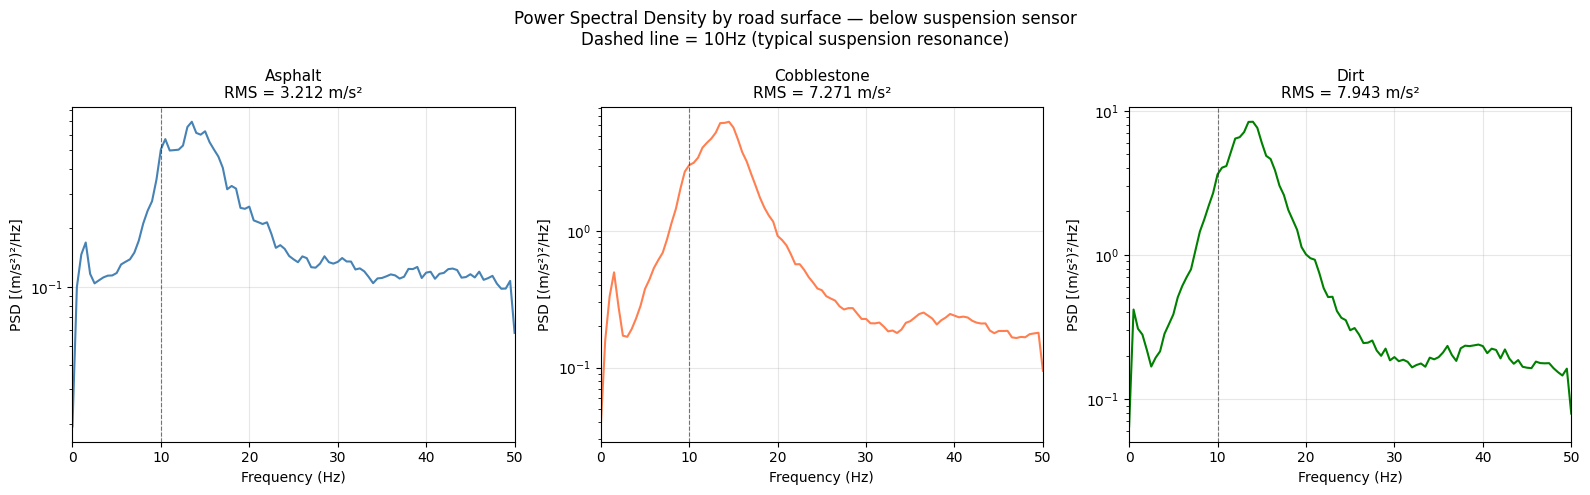


RMS by road class:
  asphalt         3.2123 m/s²  (56,509 samples, 565s)
  cobblestone     7.2715 m/s²  (61,659 samples, 617s)
  dirt            7.9430 m/s²  (25,868 samples, 259s)


In [3]:
import importlib
import src.signal_processing.spectra as spectra_mod
importlib.reload(spectra_mod)
from src.signal_processing.spectra import (
    build_spectra_export, save_spectra_export,
    build_feature_windows_export, compute_psd_by_road_class
)

# Run the module
export = build_spectra_export(datasets, config)
save_spectra_export(export, config)

# Visualize PSD by road class
psd_data = export["by_road_class"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
colors = {'asphalt': 'steelblue', 'cobblestone': 'coral', 'dirt': 'green'}

for i, (road_class, data) in enumerate(psd_data.items()):
    freqs = np.array(data["freqs"])
    psd   = np.array(data["psd_mean"])
    ax    = axes[i]
    
    ax.semilogy(freqs, psd, color=colors.get(road_class, 'gray'), linewidth=1.5)
    ax.set_title(f'{road_class.capitalize()}\nRMS = {data["rms"]:.3f} m/s²', fontsize=11)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD [(m/s²)²/Hz]')
    ax.set_xlim(0, 50)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=10, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.suptitle('Power Spectral Density by road surface — below suspension sensor\n'
             'Dashed line = 10Hz (typical suspension resonance)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nRMS by road class:")
for road_class, data in psd_data.items():
    print(f"  {road_class:<15} {data['rms']:.4f} m/s²  "
          f"({data['n_samples']:,} samples, {data['duration_sec']:.0f}s)")

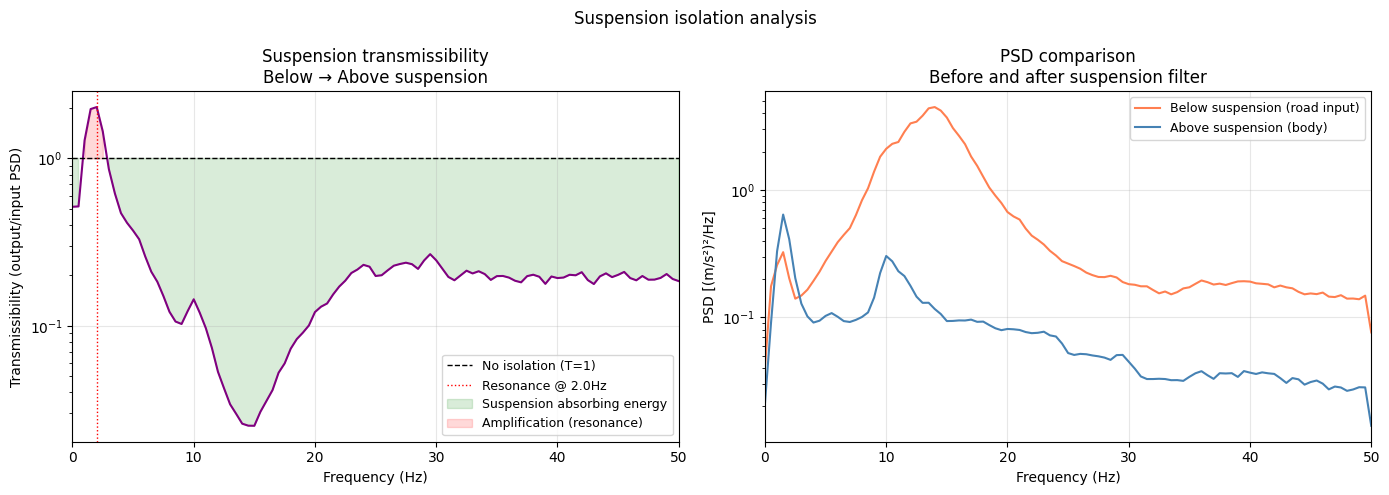


Suspension performance summary:
  Resonant frequency : 2.0 Hz
  Isolation at  5 Hz : 0.370  (absorbing)
  Isolation at 10 Hz : 0.144  (absorbing)
  Isolation at 20 Hz : 0.121  (absorbing)


In [4]:
# Transmissibility — how much vibration the suspension absorbs
trans_data = export["transmissibility"]["pvs1"]

freqs = np.array(trans_data["freqs"])
trans = np.array(trans_data["transmissibility"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: transmissibility curve
axes[0].semilogy(freqs, trans, color='purple', linewidth=1.5)
axes[0].axhline(y=1.0, color='black', linewidth=1, linestyle='--', label='No isolation (T=1)')
axes[0].axvline(x=trans_data["resonant_freq_hz"], color='red', 
                linewidth=1, linestyle=':', 
                label=f'Resonance @ {trans_data["resonant_freq_hz"]:.1f}Hz')
axes[0].fill_between(freqs, trans, 1.0, 
                      where=(trans < 1.0), alpha=0.15, color='green', 
                      label='Suspension absorbing energy')
axes[0].fill_between(freqs, trans, 1.0, 
                      where=(trans > 1.0), alpha=0.15, color='red',
                      label='Amplification (resonance)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Transmissibility (output/input PSD)')
axes[0].set_title('Suspension transmissibility\nBelow → Above suspension')
axes[0].set_xlim(0, 50)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: PSD comparison below vs above
psd_in  = np.array(trans_data["psd_input"])
psd_out = np.array(trans_data["psd_output"])

axes[1].semilogy(freqs, psd_in,  color='coral',     linewidth=1.5, label='Below suspension (road input)')
axes[1].semilogy(freqs, psd_out, color='steelblue', linewidth=1.5, label='Above suspension (body)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD [(m/s²)²/Hz]')
axes[1].set_title('PSD comparison\nBefore and after suspension filter')
axes[1].set_xlim(0, 50)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Suspension isolation analysis', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nSuspension performance summary:")
print(f"  Resonant frequency : {trans_data['resonant_freq_hz']:.1f} Hz")
print(f"  Isolation at  5 Hz : {trans_data['isolation_at_5hz']:.3f}  "
      f"({'absorbing' if trans_data['isolation_at_5hz'] < 1 else 'amplifying'})")
print(f"  Isolation at 10 Hz : {trans_data['isolation_at_10hz']:.3f}  "
      f"({'absorbing' if trans_data['isolation_at_10hz'] < 1 else 'amplifying'})")
print(f"  Isolation at 20 Hz : {trans_data['isolation_at_20hz']:.3f}  "
      f"({'absorbing' if trans_data['isolation_at_20hz'] < 1 else 'amplifying'})")

  Extracting windows: 100%|██████████| 2/2 [00:45<00:00, 22.83s/it]


  Saved feature_windows.csv — 2,931 windows, 66 features


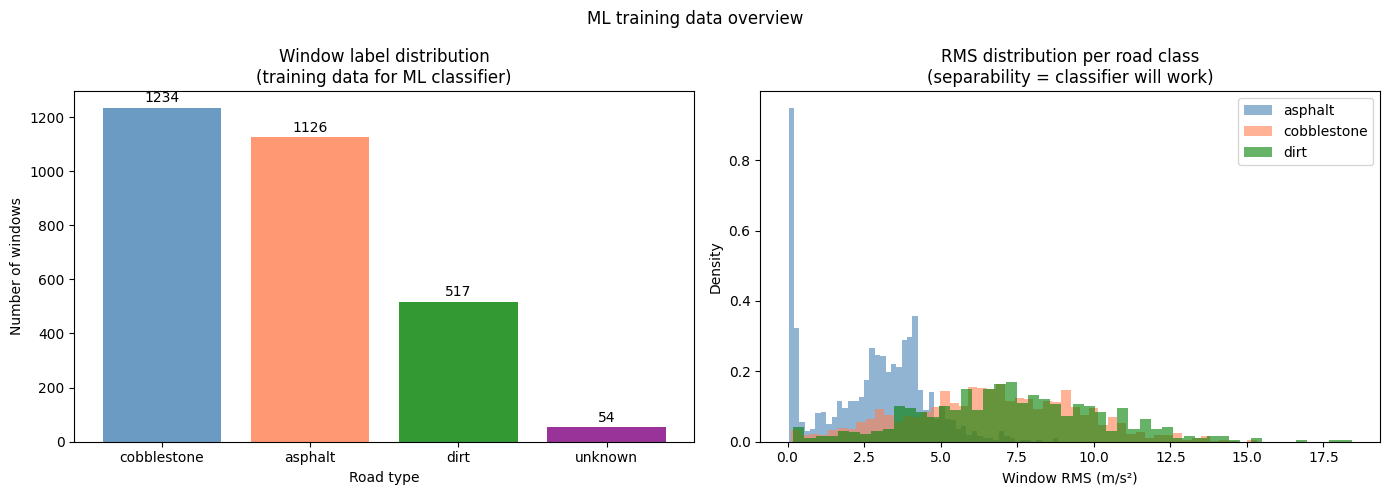


Feature windows summary:
  Total windows       : 2,931
  Features per window : 66

Label distribution:
label
cobblestone    1234
asphalt        1126
dirt            517
unknown          54
Name: count, dtype: int64


In [5]:
importlib.reload(spectra_mod)
from src.signal_processing.spectra import build_feature_windows_export

windows = build_feature_windows_export(datasets, config)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
label_counts = windows["label"].value_counts()
colors_bar   = ['steelblue', 'coral', 'green', 'purple']
axes[0].bar(label_counts.index, label_counts.values,
            color=colors_bar[:len(label_counts)], alpha=0.8)
axes[0].set_title('Window label distribution\n(training data for ML classifier)')
axes[0].set_xlabel('Road type')
axes[0].set_ylabel('Number of windows')
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 20, str(count), ha='center', fontsize=10)

# RMS distribution per road class
rms_col = 'acc_z_below_suspension_demean__rms'
colors  = {'asphalt': 'steelblue', 'cobblestone': 'coral', 'dirt': 'green'}
if rms_col in windows.columns:
    for road_class, color in colors.items():
        mask = windows["label"] == road_class
        if mask.sum() > 0:
            axes[1].hist(windows.loc[mask, rms_col], bins=50,
                        alpha=0.6, color=color, label=road_class, density=True)
    axes[1].set_xlabel('Window RMS (m/s²)')
    axes[1].set_ylabel('Density')
    axes[1].set_title('RMS distribution per road class\n(separability = classifier will work)')
    axes[1].legend()

plt.suptitle('ML training data overview', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nFeature windows summary:")
print(f"  Total windows       : {len(windows):,}")
print(f"  Features per window : {len(windows.columns)}")
print(f"\nLabel distribution:")
print(windows["label"].value_counts())

In [12]:
# Debug — check what rainflow is actually returning
import rainflow
import numpy as np

# Get the signal
df_fresh = datasets_fresh['pvs1']
signal = df_fresh["acc_z_primary"].dropna().values
print(f"Signal type: {signal.dtype}")
print(f"Signal length: {len(signal)}")

# Run rainflow directly
cycles_raw = list(rainflow.extract_cycles(signal))
print(f"\nFirst 3 cycles raw: {cycles_raw[:3]}")
print(f"Type of first cycle range: {type(cycles_raw[0][0])}")

Signal type: float64
Signal length: 144036

First 3 cycles raw: [(np.float64(0.019153613281252646), np.float64(0.04239670123925432), 1.0, 5, 6), (np.float64(0.0035913024902356483), np.float64(0.025038739203122162), 1.0, 7, 8), (np.float64(0.02154781494140856), np.float64(0.03401699542870862), 1.0, 9, 10)]
Type of first cycle range: <class 'numpy.float64'>


In [14]:
import importlib
import src.ingestion.loader as loader_mod
import src.fatigue.damage as damage_mod

importlib.reload(loader_mod)
importlib.reload(damage_mod)

from src.ingestion.loader import load_config, load_pvs_dataset
from src.fatigue.damage import build_damage_export, save_damage_export

config   = load_config()
datasets_fresh = load_pvs_dataset(config)
print("Datasets loaded fresh:", list(datasets_fresh.keys()))

print("\nRunning fatigue damage module...")
damage_export = build_damage_export(datasets_fresh, config)
save_damage_export(damage_export, config)

print("\nDamage by road class:")
for rc, data in damage_export["by_road_class"].items():
    ratio = data.get("damage_relative_to_asphalt", 1.0)
    print(f"  {rc:<15} damage index: {data['damage_index']:.4e}  "
          f"| {ratio:.1f}x asphalt | "
          f"cycles: {data['n_cycles']:,.0f}")

Found 1 datasets


Loading: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


  pvs1: 144,036 rows | 1440s | roads: {'cobblestone': 61659, 'asphalt': 56509, 'dirt': 25868} | bumps: 3455
Datasets loaded fresh: ['pvs1']

Running fatigue damage module...
  Computing per-dataset damage...


  Computing damage: 100%|██████████| 1/1 [00:00<00:00,  2.93it/s]

  Saved damage_summary.json (11 KB)

Damage by road class:
  asphalt         damage index: 0.0000e+00  | 1.0x asphalt | cycles: 16,456
  cobblestone     damage index: 1.0000e-06  | 10.1x asphalt | cycles: 14,084
  dirt            damage index: 1.0000e-06  | 5.8x asphalt | cycles: 5,604


In [15]:
# Diagnose the damage values properly
from src.fatigue.damage import rainflow_count, miners_rule

# Check each road class individually
df_fresh = datasets_fresh['pvs1']

print("Detailed damage breakdown by road class:")
print("="*60)

for road_class in ['asphalt', 'cobblestone', 'dirt']:
    mask   = df_fresh['road_type'] == road_class
    signal = df_fresh.loc[mask, 'acc_z_primary'].dropna().values
    
    rf = rainflow_count(signal)
    
    # Use smaller sn_k for better numeric resolution
    miners = miners_rule(
        cycles           = rf["cycles"],
        sn_k             = float(config["fatigue"]["sn_k"]),
        sn_m             = float(config["fatigue"]["sn_m"]),
        damage_threshold = float(config["fatigue"]["damage_threshold"]),
    )
    
    print(f"\n{road_class.upper()}")
    print(f"  Signal RMS      : {signal.std():.4f} m/s²")
    print(f"  Total cycles    : {rf['n_cycles']:,.0f}")
    print(f"  Max cycle range : {rf['range_max']:.4f} m/s²")
    print(f"  Range RMS       : {rf['range_rms']:.4f} m/s²")
    print(f"  Damage index    : {miners['damage_index']:.6e}")
    if miners['top_cycles']:
        top = miners['top_cycles'][0]
        print(f"  Most damaging cycle: range={top['range']:.3f} m/s², "
              f"count={top['count']:.1f}, damage={top['damage']:.4e}")

Detailed damage breakdown by road class:

ASPHALT
  Signal RMS      : 3.2121 m/s²
  Total cycles    : 16,456
  Max cycle range : 60.8319 m/s²
  Range RMS       : 6.8318 m/s²
  Damage index    : 1.235142e-07
  Most damaging cycle: range=51.966 m/s², count=1.0, damage=1.4033e-09

COBBLESTONE
  Signal RMS      : 7.2715 m/s²
  Total cycles    : 14,084
  Max cycle range : 114.4069 m/s²
  Range RMS       : 16.2834 m/s²
  Damage index    : 1.244802e-06
  Most damaging cycle: range=96.659 m/s², count=1.0, damage=9.0307e-09

DIRT
  Signal RMS      : 7.9429 m/s²
  Total cycles    : 5,604
  Max cycle range : 121.7236 m/s²
  Range RMS       : 17.9988 m/s²
  Damage index    : 7.144617e-07
  Most damaging cycle: range=108.160 m/s², count=1.0, damage=1.2653e-08


In [16]:
# Real damage ratios
asphalt_dmg     = 1.235142e-07
cobblestone_dmg = 1.244802e-06
dirt_dmg        = 7.144617e-07

print("Fatigue damage ratios (asphalt = 1.0 baseline):")
print(f"  Asphalt     : 1.0x")
print(f"  Cobblestone : {cobblestone_dmg/asphalt_dmg:.1f}x more damaging")
print(f"  Dirt        : {dirt_dmg/asphalt_dmg:.1f}x more damaging")

print(f"\nIn practical terms:")
print(f"  1 hour on cobblestone = {cobblestone_dmg/asphalt_dmg:.0f} hours on asphalt")
print(f"  1 hour on dirt        = {dirt_dmg/asphalt_dmg:.0f} hours on asphalt")

Fatigue damage ratios (asphalt = 1.0 baseline):
  Asphalt     : 1.0x
  Cobblestone : 10.1x more damaging
  Dirt        : 5.8x more damaging

In practical terms:
  1 hour on cobblestone = 10 hours on asphalt
  1 hour on dirt        = 6 hours on asphalt


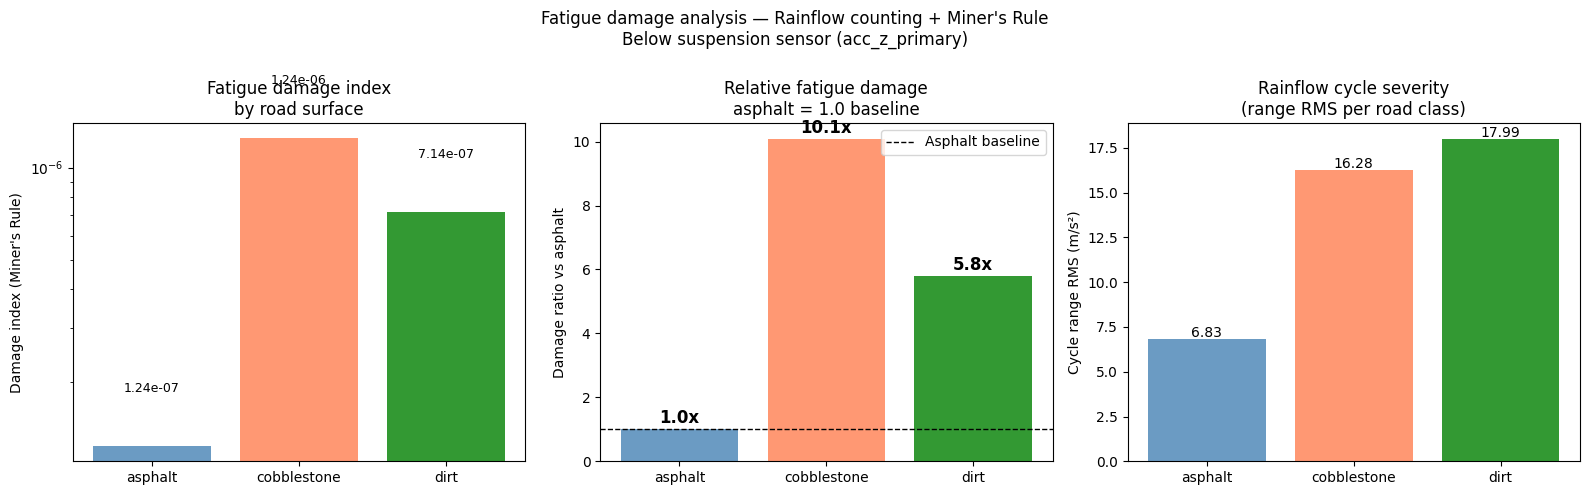


Key finding:
  Cobblestone is 10x more damaging than asphalt per unit time
  Dirt is 6x more damaging than asphalt per unit time

  This means a Rivian customer driving 10% of their miles on cobblestone
  accumulates the same fatigue damage as driving 101% on asphalt


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'asphalt': 'steelblue', 'cobblestone': 'coral', 'dirt': 'green'}

road_data = {
    'asphalt':     {'damage': asphalt_dmg,     'cycles': 16456, 'range_max': 60.83,  'range_rms': 6.83},
    'cobblestone': {'damage': cobblestone_dmg, 'cycles': 14084, 'range_max': 114.41, 'range_rms': 16.28},
    'dirt':        {'damage': dirt_dmg,        'cycles': 5604,  'range_max': 121.72, 'range_rms': 17.99},
}

# Plot 1: Damage index
road_classes = list(road_data.keys())
damage_vals  = [road_data[rc]['damage'] for rc in road_classes]
bar_colors   = [colors[rc] for rc in road_classes]

bars = axes[0].bar(road_classes, damage_vals, color=bar_colors, alpha=0.8)
axes[0].set_ylabel("Damage index (Miner's Rule)")
axes[0].set_title('Fatigue damage index\nby road surface')
axes[0].set_yscale('log')
for bar, val in zip(bars, damage_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val * 1.5,
                f'{val:.2e}', ha='center', fontsize=9)

# Plot 2: Damage ratio vs asphalt
ratios = [road_data[rc]['damage'] / asphalt_dmg for rc in road_classes]
bars2  = axes[1].bar(road_classes, ratios, color=bar_colors, alpha=0.8)
axes[1].axhline(y=1.0, color='black', linewidth=1,
                linestyle='--', label='Asphalt baseline')
axes[1].set_ylabel('Damage ratio vs asphalt')
axes[1].set_title('Relative fatigue damage\nasphalt = 1.0 baseline')
axes[1].legend()
for bar, val in zip(bars2, ratios):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                f'{val:.1f}x', ha='center', fontsize=12, fontweight='bold')

# Plot 3: Cycle range RMS (input severity)
range_rms = [road_data[rc]['range_rms'] for rc in road_classes]
bars3 = axes[2].bar(road_classes, range_rms, color=bar_colors, alpha=0.8)
axes[2].set_ylabel('Cycle range RMS (m/s²)')
axes[2].set_title('Rainflow cycle severity\n(range RMS per road class)')
for bar, val in zip(bars3, range_rms):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle("Fatigue damage analysis — Rainflow counting + Miner's Rule\n"
             "Below suspension sensor (acc_z_primary)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey finding:")
print(f"  Cobblestone is {cobblestone_dmg/asphalt_dmg:.0f}x more damaging than asphalt per unit time")
print(f"  Dirt is {dirt_dmg/asphalt_dmg:.0f}x more damaging than asphalt per unit time")
print(f"\n  This means a Rivian customer driving 10% of their miles on cobblestone")
print(f"  accumulates the same fatigue damage as driving {cobblestone_dmg/asphalt_dmg*10:.0f}% on asphalt")

In [18]:
from src.fatigue.damage import rainflow_count, miners_rule, fit_weibull
import warnings
warnings.filterwarnings('ignore')

# Compute damage index per window
print("Computing damage per window (this takes ~1 min)...")

df_fresh   = datasets_fresh['pvs1']
window_size = config["ml"]["window_size_samples"]  # 200 samples = 2 seconds
stride      = config["ml"]["window_stride_samples"] # 50 samples
sn_k        = float(config["fatigue"]["sn_k"])
sn_m        = float(config["fatigue"]["sn_m"])
threshold   = float(config["fatigue"]["damage_threshold"])

signal      = df_fresh["acc_z_primary"].dropna().values
road_types  = df_fresh["road_type"].values

window_records = []

for start in range(0, len(signal) - window_size, stride):
    end    = start + window_size
    window = signal[start:end]

    # Road type for this window
    road_window = road_types[start:end]
    road_label  = pd.Series(road_window).mode().iloc[0]

    # Rainflow + Miner's
    rf     = rainflow_count(window)
    if not rf["cycles"]:
        continue

    miners = miners_rule(rf["cycles"], sn_k, sn_m, threshold)

    window_records.append({
        "window_start":  start,
        "road_type":     road_label,
        "damage_index":  miners["damage_index"],
        "n_cycles":      rf["n_cycles"],
        "range_max":     rf["range_max"],
    })

window_dmg_df = pd.DataFrame(window_records)
print(f"Computed damage for {len(window_dmg_df):,} windows")
print(f"\nDamage index stats:")
print(window_dmg_df.groupby("road_type")["damage_index"].describe().round(8))

Computing damage per window (this takes ~1 min)...
Computed damage for 2,877 windows

Damage index stats:
              count          mean           std  min  25%  50%           75%  \
road_type                                                                      
asphalt      1126.0  0.000000e+00  0.000000e+00  0.0  0.0  0.0  0.000000e+00   
cobblestone  1234.0  0.000000e+00  0.000000e+00  0.0  0.0  0.0  1.000000e-08   
dirt          517.0  1.000000e-08  1.000000e-08  0.0  0.0  0.0  1.000000e-08   

                      max  
road_type                  
asphalt      1.000000e-08  
cobblestone  3.000000e-08  
dirt         6.000000e-08  



ASPHALT Weibull fit:
  β (shape)    : 0.340  → infant mortality
  η (scale)    : 0.000000e+00
  P50 damage   : 6.1605e-11
  P90 damage   : 2.1103e-09
  P99 damage   : 1.6234e-08

COBBLESTONE Weibull fit:
  β (shape)    : 0.806  → random failures
  η (scale)    : 0.000000e+00
  P50 damage   : 2.2240e-09
  P90 damage   : 9.8633e-09
  P99 damage   : 2.3308e-08

DIRT Weibull fit:
  β (shape)    : 0.807  → random failures
  η (scale)    : 0.000000e+00
  P50 damage   : 2.9957e-09
  P90 damage   : 1.3265e-08
  P99 damage   : 3.1319e-08


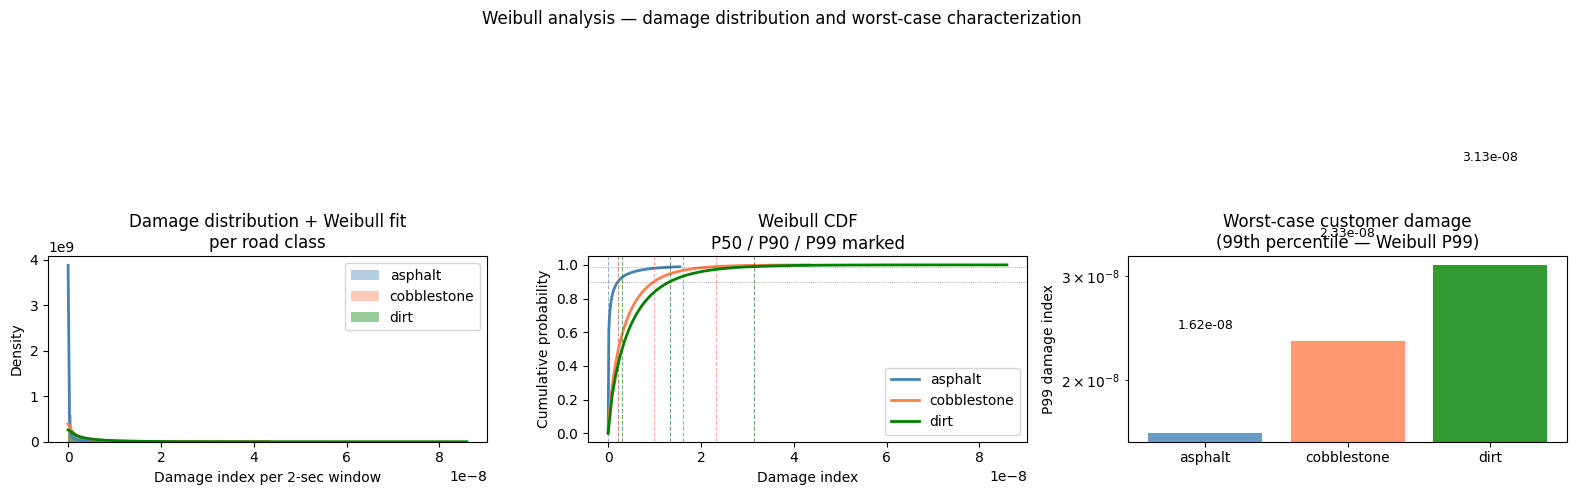


Key Rivian insight:
The P99 damage value is the design target —
the component must survive the worst 1% of usage scenarios.
  asphalt         P99 = 1.623e-08  β = 0.34 (infant mortality)
  cobblestone     P99 = 2.331e-08  β = 0.81 (random failures)
  dirt            P99 = 3.132e-08  β = 0.81 (random failures)


In [19]:
from src.fatigue.damage import fit_weibull
from scipy.stats import weibull_min

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

road_classes = ['asphalt', 'cobblestone', 'dirt']
colors       = {'asphalt': 'steelblue', 'cobblestone': 'coral', 'dirt': 'green'}

weibull_results = {}

for road_class in road_classes:
    mask   = window_dmg_df["road_type"] == road_class
    values = window_dmg_df.loc[mask, "damage_index"].values
    values = values[values > 0]

    if len(values) < 10:
        continue

    result = fit_weibull(values.tolist())
    weibull_results[road_class] = result

    if "error" in result or "note" in result:
        print(f"{road_class}: {result}")
        continue

    color = colors[road_class]

    # Plot 1: Histogram + Weibull PDF
    axes[0].hist(values, bins=40, density=True,
                 alpha=0.4, color=color, label=road_class)
    x    = np.array(result["plot_x"])
    # Compute PDF from CDF
    pdf  = np.gradient(result["plot_cdf"], x)
    axes[0].plot(x, pdf, color=color, linewidth=2)

    print(f"\n{road_class.upper()} Weibull fit:")
    print(f"  β (shape)    : {result['shape_beta']:.3f}  → {result['failure_mode']}")
    print(f"  η (scale)    : {result['scale_eta']:.6e}")
    print(f"  P50 damage   : {result['p50_damage']:.4e}")
    print(f"  P90 damage   : {result['p90_damage']:.4e}")
    print(f"  P99 damage   : {result['p99_damage']:.4e}")

axes[0].set_xlabel("Damage index per 2-sec window")
axes[0].set_ylabel("Density")
axes[0].set_title("Damage distribution + Weibull fit\nper road class")
axes[0].legend()

# Plot 2: Weibull CDF per road class
for road_class, result in weibull_results.items():
    if "error" in result or "note" in result:
        continue
    axes[1].plot(result["plot_x"], result["plot_cdf"],
                 color=colors[road_class], linewidth=2, label=road_class)
    # Mark P50, P90, P99
    for p, val in [("P50", result["p50_damage"]),
                   ("P90", result["p90_damage"]),
                   ("P99", result["p99_damage"])]:
        axes[1].axvline(x=val, color=colors[road_class],
                       linewidth=0.8, linestyle='--', alpha=0.6)

axes[1].set_xlabel("Damage index")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("Weibull CDF\nP50 / P90 / P99 marked")
axes[1].legend()
axes[1].axhline(y=0.99, color='black', linewidth=0.5,
                linestyle=':', alpha=0.5, label='P99')
axes[1].axhline(y=0.90, color='black', linewidth=0.5,
                linestyle=':', alpha=0.5, label='P90')

# Plot 3: P99 damage comparison (worst case customer)
p99_values = {rc: weibull_results[rc]["p99_damage"]
              for rc in road_classes
              if rc in weibull_results and "p99_damage" in weibull_results[rc]}

bars = axes[2].bar(
    list(p99_values.keys()),
    list(p99_values.values()),
    color=[colors[rc] for rc in p99_values.keys()],
    alpha=0.8
)
axes[2].set_ylabel("P99 damage index")
axes[2].set_title("Worst-case customer damage\n(99th percentile — Weibull P99)")
axes[2].set_yscale('log')
for bar, val in zip(bars, p99_values.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, val * 1.5,
                f'{val:.2e}', ha='center', fontsize=9)

plt.suptitle("Weibull analysis — damage distribution and worst-case characterization",
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey Rivian insight:")
print("The P99 damage value is the design target —")
print("the component must survive the worst 1% of usage scenarios.")
for rc, result in weibull_results.items():
    if "p99_damage" in result:
        ratio = result["p99_damage"] / weibull_results.get(
            "asphalt", {}).get("p99_damage", result["p99_damage"])
        print(f"  {rc:<15} P99 = {result['p99_damage']:.3e}  "
              f"β = {result['shape_beta']:.2f} ({result['failure_mode']})")

In [20]:
# Add damage index to feature windows
print("Adding damage index to feature windows...")

window_dmg_df_indexed = window_dmg_df.reset_index(drop=True)
windows_indexed       = windows.reset_index(drop=True)

# Merge on window_start
windows_with_damage = windows_indexed.merge(
    window_dmg_df[["window_start", "damage_index", "n_cycles", "range_max"]],
    on="window_start",
    how="left"
)
windows_with_damage["damage_index"] = windows_with_damage["damage_index"].fillna(0)

print(f"Windows with damage: {len(windows_with_damage):,}")
print(f"Non-zero damage:     {(windows_with_damage['damage_index'] > 0).sum():,}")
print(f"Columns:             {len(windows_with_damage.columns)}")

Adding damage index to feature windows...
Windows with damage: 2,931
Non-zero damage:     2,931
Columns:             69


In [21]:
import src.ml.classifier as clf_mod
importlib.reload(clf_mod)
from src.ml.classifier import build_ml_export, save_ml_export

print("Training ML models...")
ml_export, clf_model, reg_model = build_ml_export(
    windows_with_damage, config, damage_col="damage_index"
)
save_ml_export(ml_export, config)

Training ML models...

[1/3] Road surface classifier
  Feature matrix: 2,931 samples × 64 features
  Training Random Forest (200 trees)...
  Accuracy: 0.939 | CV: 0.945 ± 0.011

[2/3] Fatigue damage regressor
  Preparing damage regression features...
  Feature matrix: 2,931 samples × 63 features
  Training XGBoost regressor...
  R² score: 1.000 | MAE (log scale): 0.026

[3/3] Usage archetype clustering
  K-Means clustering with k=4...
  Clustered 2,931 windows into 4 archetypes
    Cluster 0: 953 windows | mixed use driver | dominant road: cobblestone
    Cluster 1: 757 windows | mixed use driver | dominant road: asphalt
    Cluster 2: 4 windows | city driver | dominant road: asphalt
    Cluster 3: 1,217 windows | off-road / rough road user | dominant road: cobblestone

  Saved ml_results.json (68 KB)


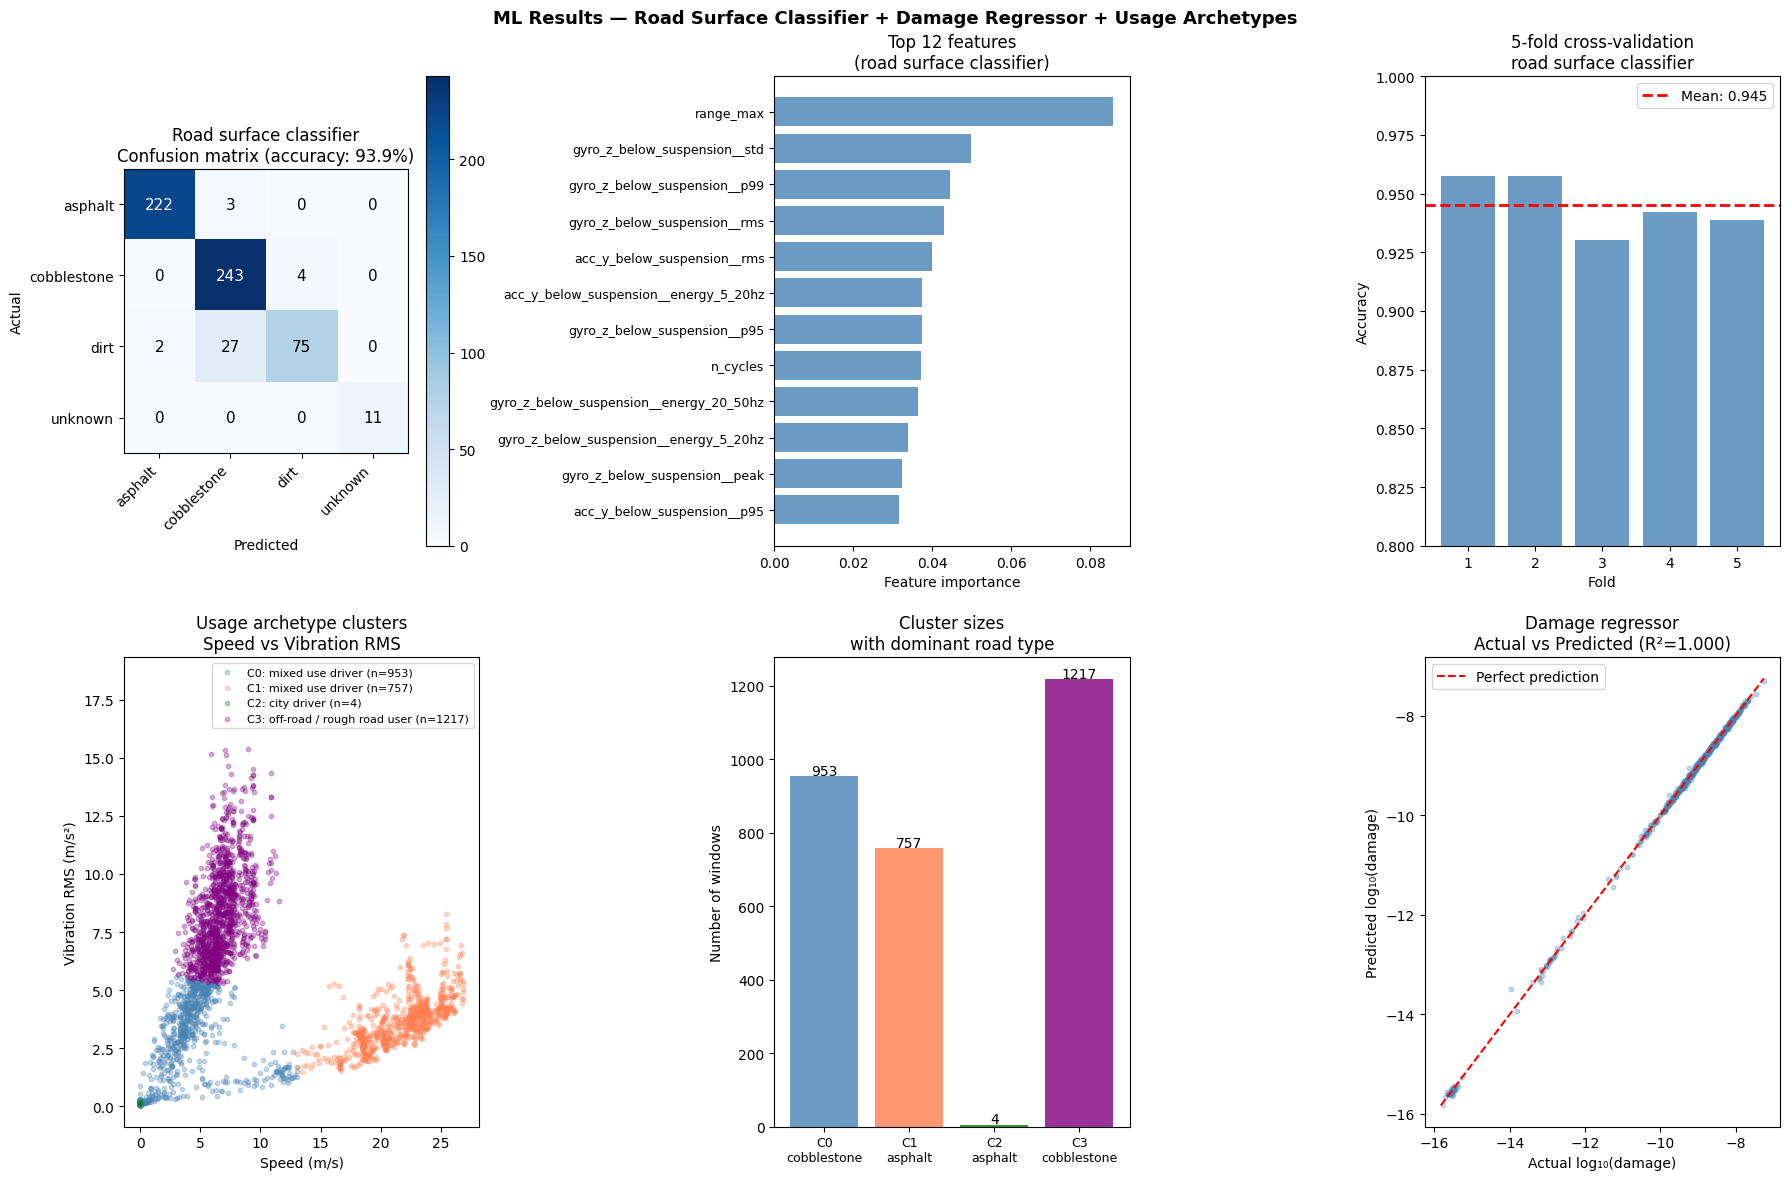


Summary:
  Classifier accuracy : 93.9%
  CV accuracy         : 94.5% ± 1.1%
  Damage regressor R² : 1.000
  Usage archetypes    : 4 clusters found


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(18, 12))

# ================================================================
# Row 1: Classifier results
# ================================================================

# Plot 1: Confusion matrix
ax1 = fig.add_subplot(2, 3, 1)
cm      = np.array(ml_export["classifier"]["confusion_matrix"])
classes = ml_export["classifier"]["classes"]

im = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
ax1.set_xticks(range(len(classes)))
ax1.set_yticks(range(len(classes)))
ax1.set_xticklabels(classes, rotation=45, ha='right')
ax1.set_yticklabels(classes)

# Annotate cells
thresh = cm.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        ax1.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=11,
                color='white' if cm[i, j] > thresh else 'black')

ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Road surface classifier\nConfusion matrix '
              f'(accuracy: {ml_export["classifier"]["accuracy"]:.1%})')
plt.colorbar(im, ax=ax1)

# Plot 2: Top feature importances
ax2 = fig.add_subplot(2, 3, 2)
top_feats = ml_export["classifier"]["top_features"][:12]
feat_names = [f["feature"].replace("acc_z_below_suspension_demean__", "below__")
                          .replace("acc_z_above_suspension_demean__", "above__")
              for f in top_feats]
feat_vals  = [f["importance"] for f in top_feats]

bars = ax2.barh(range(len(feat_names)), feat_vals, color='steelblue', alpha=0.8)
ax2.set_yticks(range(len(feat_names)))
ax2.set_yticklabels(feat_names, fontsize=9)
ax2.set_xlabel('Feature importance')
ax2.set_title('Top 12 features\n(road surface classifier)')
ax2.invert_yaxis()

# Plot 3: CV scores
ax3 = fig.add_subplot(2, 3, 3)
cv_scores = ml_export["classifier"]["cv_scores"]
ax3.bar(range(1, len(cv_scores)+1), cv_scores,
        color='steelblue', alpha=0.8)
ax3.axhline(y=np.mean(cv_scores), color='red',
            linewidth=2, linestyle='--',
            label=f'Mean: {np.mean(cv_scores):.3f}')
ax3.set_xlabel('Fold')
ax3.set_ylabel('Accuracy')
ax3.set_title('5-fold cross-validation\nroad surface classifier')
ax3.set_ylim(0.8, 1.0)
ax3.legend()

# ================================================================
# Row 2: Clustering results
# ================================================================

# Plot 4: Cluster scatter — RMS vs Speed
ax4 = fig.add_subplot(2, 3, 4)
cluster_colors  = ['steelblue', 'coral', 'green', 'purple']
cluster_labels  = ml_export["clustering"]["cluster_labels"] \
    if "cluster_labels" in ml_export["clustering"] \
    else ml_export["clustering"]["labels"]

rms_col   = "acc_z_below_suspension_demean__rms"
speed_col = "speed_mean"

if rms_col in windows_with_damage.columns and speed_col in windows_with_damage.columns:
    for i in range(ml_export["clustering"]["n_clusters"]):
        mask = np.array(cluster_labels) == i
        profile  = ml_export["clustering"]["cluster_profiles"][i]
        archetype = profile.get("archetype", f"cluster {i}")
        ax4.scatter(
            windows_with_damage.loc[mask, speed_col],
            windows_with_damage.loc[mask, rms_col],
            c=cluster_colors[i], alpha=0.3, s=10,
            label=f'C{i}: {archetype} (n={profile["n_windows"]})'
        )

ax4.set_xlabel('Speed (m/s)')
ax4.set_ylabel('Vibration RMS (m/s²)')
ax4.set_title('Usage archetype clusters\nSpeed vs Vibration RMS')
ax4.legend(fontsize=8, loc='upper right')

# Plot 5: Cluster size and dominant road
ax5 = fig.add_subplot(2, 3, 5)
profiles  = ml_export["clustering"]["cluster_profiles"]
n_windows = [p["n_windows"] for p in profiles]
archetypes = [p.get("archetype", f"C{p['cluster_id']}") for p in profiles]

bars5 = ax5.bar(range(len(profiles)), n_windows,
                color=cluster_colors[:len(profiles)], alpha=0.8)
ax5.set_xticks(range(len(profiles)))
ax5.set_xticklabels([f'C{p["cluster_id"]}\n{p.get("dominant_road","?")}' 
                     for p in profiles], fontsize=9)
ax5.set_ylabel('Number of windows')
ax5.set_title('Cluster sizes\nwith dominant road type')
for bar, val in zip(bars5, n_windows):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 5,
             str(val), ha='center', fontsize=10)

# Plot 6: Regressor predicted vs actual
ax6 = fig.add_subplot(2, 3, 6)
if "y_test" in ml_export["regressor"] and "y_pred" in ml_export["regressor"]:
    y_test_vals = ml_export["regressor"]["y_test"]
    y_pred_vals = ml_export["regressor"]["y_pred"]
    ax6.scatter(y_test_vals, y_pred_vals,
                alpha=0.3, s=10, color='steelblue')
    min_val = min(min(y_test_vals), min(y_pred_vals))
    max_val = max(max(y_test_vals), max(y_pred_vals))
    ax6.plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect prediction')
    ax6.set_xlabel('Actual log₁₀(damage)')
    ax6.set_ylabel('Predicted log₁₀(damage)')
    ax6.set_title(f'Damage regressor\nActual vs Predicted '
                  f'(R²={ml_export["regressor"]["r2_score"]:.3f})')
    ax6.legend()

plt.suptitle('ML Results — Road Surface Classifier + '
             'Damage Regressor + Usage Archetypes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  Classifier accuracy : {ml_export['classifier']['accuracy']:.1%}")
print(f"  CV accuracy         : {ml_export['classifier']['cv_accuracy_mean']:.1%} "
      f"± {ml_export['classifier']['cv_accuracy_std']:.1%}")
print(f"  Damage regressor R² : {ml_export['regressor']['r2_score']:.3f}")
print(f"  Usage archetypes    : {ml_export['clustering']['n_clusters']} clusters found")

  K=2: inertia=8705.7
  K=3: inertia=5954.9
  K=4: inertia=3961.4
  K=5: inertia=3168.6
  K=6: inertia=2503.8
  K=7: inertia=2094.0
  K=8: inertia=1859.5


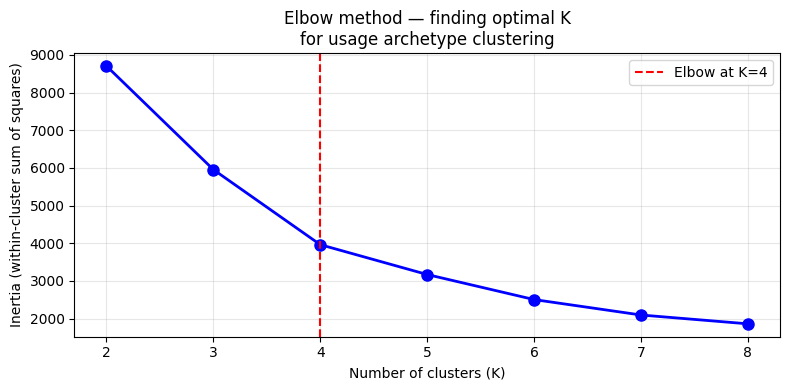


Suggested optimal K: 4
Update config.yaml: clustering: n_clusters: 4


In [24]:
from sklearn.cluster import KMeans

# Elbow method to find optimal K
rms_col   = "acc_z_below_suspension_demean__rms"
speed_col = "speed_mean"
kurt_col  = "acc_z_below_suspension_demean__kurtosis"
crest_col = "acc_z_below_suspension_demean__crest_factor"

available_cols = [c for c in [rms_col, speed_col, kurt_col, crest_col] 
                  if c in windows_with_damage.columns]

X_cluster = windows_with_damage[available_cols].fillna(0)

from sklearn.preprocessing import StandardScaler
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
k_range  = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k}: inertia={km.inertia_:.1f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow method — finding optimal K\nfor usage archetype clustering')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)

# Mark the elbow
diffs      = np.diff(inertias)
diffs2     = np.diff(diffs)
elbow_k    = list(k_range)[np.argmax(diffs2) + 1]
plt.axvline(x=elbow_k, color='red', linewidth=1.5,
            linestyle='--', label=f'Elbow at K={elbow_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nSuggested optimal K: {elbow_k}")
print("Update config.yaml: clustering: n_clusters:", elbow_k)